# OCR-based Image Classification

This notebook extracts text from images using OCR (pytesseract) and trains a text classifier (TF-IDF + Logistic Regression) to predict the image class. It includes data collection, OCR extraction, model training, evaluation, inference, and artifact saving.

In [18]:
# Install required Python packages if missing (won't install system Tesseract)
import importlib, subprocess, sys
def ensure_package(pkg, import_name=None):
    m = import_name or pkg
    try:
        importlib.import_module(m)
        print(f'OK: {pkg} available')
    except ModuleNotFoundError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

ensure_package('pytesseract')
ensure_package('pillow', 'PIL')
ensure_package('scikit-learn', 'sklearn')
ensure_package('joblib')
ensure_package('pandas')
ensure_package('tqdm')
ensure_package('numpy')

OK: pytesseract available
OK: pillow available
OK: scikit-learn available
OK: joblib available
OK: pandas available
OK: tqdm available
OK: numpy available


In [19]:
# Imports
from pathlib import Path
from PIL import Image
import pytesseract
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from joblib import dump, load
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [20]:
# Configuration - workspace-relative paths
ROOT = Path('..').resolve()  # notebook is in TFM/ folder, Data is at workspace root
DATA_DIR = (ROOT / 'Data')
MODELS_DIR = Path('Models')
MODELS_DIR.mkdir(exist_ok=True)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
print('Data dir:', DATA_DIR)
print('Models dir:', MODELS_DIR.resolve())

Data dir: C:\Users\ibf\Desktop\TFM\Nou projecte\Data
Models dir: C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models


In [21]:
# Collect top-level class image paths (same convention as other notebooks)
def collect_top_level_samples(root_dir):
    root = Path(root_dir)
    classes = sorted([p.name for p in root.iterdir() if p.is_dir()])
    samples = []
    for idx, cname in enumerate(classes):
        for img in (root / cname).rglob('*'):
            if img.is_file() and img.suffix.lower() in IMAGE_EXTENSIONS:
                samples.append((str(img), cname))
    return classes, samples

classes, samples = collect_top_level_samples(DATA_DIR)
print('Found classes:', classes)
print('Total images found:', len(samples))

Found classes: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Total images found: 2764


In [22]:
# Quick Tesseract availability check
try:
    print('pytesseract version:', pytesseract.get_tesseract_version())
except Exception as e:
    # Try to locate common install paths and configure pytesseract to use them
    import os
    possible = [
        r'C:\Program Files\Tesseract-OCR\tesseract.exe',
        r'C:\Program Files (x86)\Tesseract-OCR\tesseract.exe',
        os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Programs', 'Tesseract-OCR', 'tesseract.exe')
    ]
    found = False
    for tesseract_path in possible:
        if tesseract_path and os.path.exists(tesseract_path):
            pytesseract.pytesseract.tesseract_cmd = tesseract_path
            try:
                print('pytesseract version:', pytesseract.get_tesseract_version())
                found = True
                break
            except Exception as e2:
                print('Tesseract found but pytesseract still cannot access it:', e2)
    if not found:
        print('Warning: Tesseract not available or not found by pytesseract. You must install Tesseract-OCR separately for OCR to work.')
        print('On Windows, install from https://github.com/tesseract-ocr/tesseract and set pytesseract.pytesseract.tesseract_cmd if needed.')


pytesseract version: 5.5.0.20241111


In [23]:
# Build a dataframe with OCR-extracted text and labels (this can be slow)
def extract_text_from_image(path, crop_top=120, crop_bottom=120):
    try:
        img = Image.open(path).convert('RGB')
        w, h = img.size
        # Only crop if image is taller than the combined crop margins
        if h > (crop_top + crop_bottom):
            top = int(crop_top)
            bottom = int(h - crop_bottom)
            if top < bottom:
                img = img.crop((0, top, w, bottom))
        text = pytesseract.image_to_string(img)
        return text.strip()
    except Exception as e:
        return ''

records = []
for img_path, label in tqdm(samples, desc='OCR pass'):
    txt = extract_text_from_image(img_path)
    records.append({'path': img_path, 'label': label, 'text': txt})

df = pd.DataFrame(records)
# Optionally drop empty-text rows or keep them (they may still carry signal)
print('Samples with empty OCR text:', (df['text']=="").sum())
df.head()

OCR pass: 100%|██████████| 2764/2764 [35:37<00:00,  1.29it/s]

Samples with empty OCR text: 132


,path,label,text
0,C:\Users\ibf\Desktop\TFM\Nou projecte\Data\Ban...,Banner aplicación,Informacion sobre los\nDatos mostrados en\nCai...
1,C:\Users\ibf\Desktop\TFM\Nou projecte\Data\Ban...,Banner aplicación,Informacion sobre los Datos mostrados\nen Caix...
2,C:\Users\ibf\Desktop\TFM\Nou projecte\Data\Ban...,Banner aplicación,Informacion sobre los\nDatos mostrados en\nCai...
3,C:\Users\ibf\Desktop\TFM\Nou projecte\Data\Ban...,Banner aplicación,Informacion sobre los\nDatos mostrados en\nCai...
4,C:\Users\ibf\Desktop\TFM\Nou projecte\Data\Ban...,Banner aplicación,Actualiza la app\n\nEsta version de la app dej...


Train samples: 2211 Val samples: 553


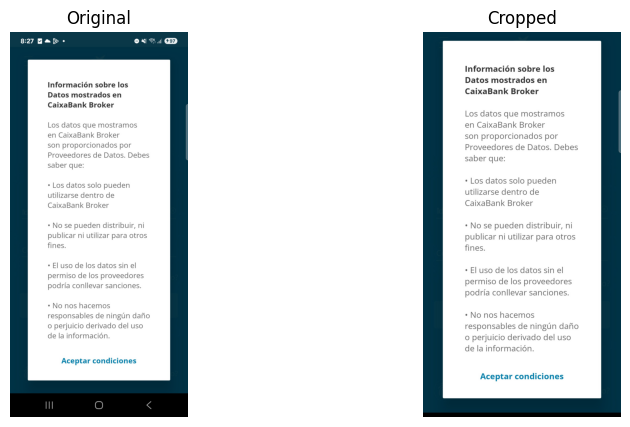

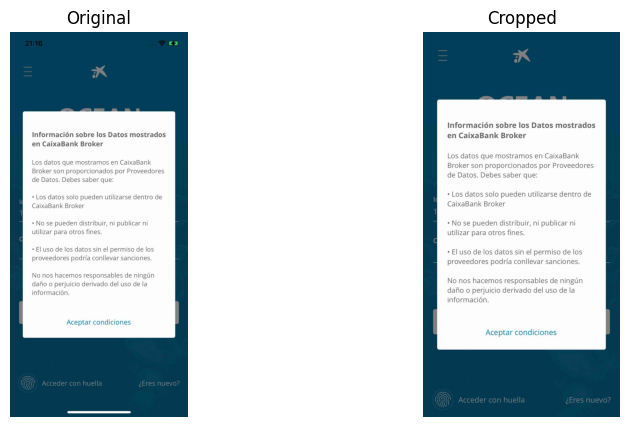

In [24]:
# Prepare dataset for text classification
X = df['text'].fillna('')
y = df['label']

# Train/val split stratified by label
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train samples:', len(X_train), 'Val samples:', len(X_val))

# Vectorize text (skip if no text available)
from sklearn.exceptions import NotFittedError
try:
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
    X_train_t = vectorizer.fit_transform(X_train)
    X_val_t = vectorizer.transform(X_val)
except ValueError:
    print('Vectorizer: empty vocabulary, skipping vectorization (no OCR text).')
    vectorizer = None
    X_train_t = None
    X_val_t = None

# --- Visualize cropping: show 1-2 examples original vs cropped ---
import matplotlib.pyplot as plt

def get_cropped_image(path, crop_top=120, crop_bottom=120):
    img = Image.open(path).convert('RGB')
    w,h = img.size
    if h > (crop_top + crop_bottom):
        top = int(crop_top)
        bottom = int(h - crop_bottom)
        if top < bottom:
            cropped = img.crop((0, top, w, bottom))
        else:
            cropped = img.copy()
    else:
        cropped = img.copy()
    return img, cropped

n = min(2, len(df))
for i in range(n):
    orig, cropped = get_cropped_image(df.loc[i,'path'])
    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(orig); axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(cropped); axes[1].set_title('Cropped'); axes[1].axis('off')
    plt.show()


In [25]:
# Train a simple Logistic Regression classifier
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_t, y_train)

# Evaluate
y_pred = clf.predict(X_val_t)
print('Accuracy:', accuracy_score(y_val, y_pred))
print('\nClassification report:')
print(classification_report(y_val, y_pred))


Accuracy: 0.9276672694394213

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      0.95      0.97        20
Cierre aplicación       0.97      0.90      0.93        31
 Error aplicativo       1.00      0.97      0.99        36
  Error funcional       0.99      0.98      0.99       107
   Error terminal       1.00      0.99      0.99        81
    Indeterminado       0.06      0.67      0.11         3
Revisión circuito       0.98      0.98      0.98       236
          Timeout       0.81      0.33      0.47        39

         accuracy                           0.93       553
        macro avg       0.85      0.85      0.80       553
     weighted avg       0.97      0.93      0.94       553



In [26]:
# Save artifacts: vectorizer + classifier
dump(vectorizer, MODELS_DIR / 'ocr_vectorizer.joblib')
dump(clf, MODELS_DIR / 'ocr_text_classifier.joblib')
df.to_csv(MODELS_DIR / 'ocr_samples.csv', index=False)
print('Saved vectorizer and classifier to', MODELS_DIR)

Saved vectorizer and classifier to Models


In [33]:
# Inference helper: given an image, extract text and predict class
def predict_image_class_from_ocr(image_path, vectorizer_path=MODELS_DIR / 'ocr_vectorizer.joblib', clf_path=MODELS_DIR / 'ocr_text_classifier.joblib', confidence_threshold=0.5):
    vec = load(vectorizer_path)
    model = load(clf_path)
    txt = extract_text_from_image(image_path)
    # Map empty OCR to Indeterminado
    if not txt:
        return {'predicted': 'Indeterminado', 'confidence': 0.0, 'text': ''}
    vt = vec.transform([txt])
    probs = model.predict_proba(vt)[0]
    idx = probs.argmax()
    label = model.classes_[idx]
    confidence = float(probs[idx])
    # Map low-confidence predictions to Indeterminado
    if confidence < confidence_threshold:
        return {'predicted': 'Indeterminado', 'confidence': confidence, 'text': txt}
    return {'predicted': label, 'confidence': confidence, 'text': txt}

# Example: predict on first validation sample if available (guarded)
try:
    if 'X_val' in globals() and len(X_val) > 0 and 'df' in globals():
        example_path = df.loc[X_val.index[0], 'path']
        print('Example path:', example_path)
        print(predict_image_class_from_ocr(example_path))
except Exception:
    pass


---
Notes:
- This approach relies on Tesseract-OCR being installed on your system. On Windows, install Tesseract and set `pytesseract.pytesseract.tesseract_cmd` to the tesseract executable path if needed.
- If OCR text is sparse or unreliable, consider a hybrid approach: combine image-based CNN features with OCR text features, or train an end-to-end image classifier.

In [28]:
# Write a minimal requirements.txt for this notebook
reqs = ['pytesseract', 'pillow', 'scikit-learn', 'joblib', 'pandas', 'tqdm', 'numpy']
with open('requirements_ocr.txt', 'w') as f:
    f.write('\n'.join(reqs))
print('requirements_ocr.txt created')


requirements_ocr.txt created


In [ ]:
# Classify all images under VAL and move them into the real class folders
from collections import Counter
import shutil

VAL_INPUT_DIR = ROOT / 'VAL'
TEMP_OUTPUT_DIR = VAL_INPUT_DIR / 'classified_ocr'
MODEL_VECTOR_PATH = MODELS_DIR / 'ocr_vectorizer.joblib'
MODEL_CLF_PATH = MODELS_DIR / 'ocr_text_classifier.joblib'
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

# Remove any previous staging output from earlier attempts
if TEMP_OUTPUT_DIR.exists():
    shutil.rmtree(TEMP_OUTPUT_DIR)

vec = load(MODEL_VECTOR_PATH)
model = load(MODEL_CLF_PATH)


def predict_image_class_from_ocr_local(image_path, confidence_threshold=0.5):
    text = extract_text_from_image(image_path)
    # Map empty OCR to Indeterminado
    if not text:
        return 'Indeterminado', 0.0, text
    text_vector = vec.transform([text])
    probs = model.predict_proba(text_vector)[0]
    best_idx = probs.argmax()
    predicted = model.classes_[best_idx]
    confidence = float(probs[best_idx])
    # Map low-confidence predictions to Indeterminado
    if confidence < confidence_threshold:
        return 'Indeterminado', confidence, text
    return predicted, confidence, text

# Capture the file list before moving anything
all_images = [
    path for path in VAL_INPUT_DIR.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_EXTS and TEMP_OUTPUT_DIR not in path.parents
]

results = []
label_counts = Counter()

for image_path in tqdm(all_images, desc='Classifying VAL images'):
    predicted_label, confidence, text = predict_image_class_from_ocr_local(image_path)

    label_counts[predicted_label] += 1

    target_dir = VAL_INPUT_DIR / predicted_label
    target_dir.mkdir(parents=True, exist_ok=True)

    destination = target_dir / image_path.name
    if destination.exists() and destination.resolve() != image_path.resolve():
        destination = target_dir / image_path.relative_to(VAL_INPUT_DIR).as_posix().replace('/', '__')

    if image_path.resolve() != destination.resolve():
        shutil.move(str(image_path), str(destination))

    results.append({
        'source_path': str(image_path),
        'predicted_label': predicted_label,
        'confidence': confidence,
        'text': text,
        'destination_path': str(destination),
    })

val_results = pd.DataFrame(results)
val_results.to_csv(VAL_INPUT_DIR / 'val_classification_results.csv', index=False)

print('Classified images:', len(val_results))
print('Output folder:', VAL_INPUT_DIR)
print('Predicted counts:')
for label, count in label_counts.most_common():
    print(f'  {label}: {count}')


Classifying VAL images: 100%|██████████| 1690/1690 [26:24<00:00,  1.07it/s]

Classified images: 1690
Output folder: C:\Users\ibf\Desktop\TFM\Nou projecte\VAL
Predicted counts:
  uncertain: 786
  Revisión circuito: 506
  Error aplicativo: 95
  Error terminal: 88
  unknown: 82
  Cierre aplicación: 69
  Banner aplicación: 26
  Timeout: 19
  Error funcional: 17
  Indeterminado: 2
